# TS3 - Simulación de un ADC

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Generador de señales (de TS1)

In [33]:
class GeneradorSenales:

    @staticmethod
    def _generar_tiempo(n, fs):
        return (np.arange(n) / fs).reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):
        tt = GeneradorSenales._generar_tiempo(n, fs)
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx

## Cuantizador

Implementamos un cuantizador *mid-tread* (incluye el nivel cero) con redondeo al nivel más cercano y saturación a $\pm V_F$:

$$q = \frac{V_{FS}}{2^B} = \frac{2\,V_F}{2^B}$$

luego saturado al rango $[-V_F,\, V_F]$.

In [34]:
def cuantizar(sR, B, Vf):
    """
    Parametros
    ----------
    sR : array_like
        Senial de entrada .
    B : int
        Cantidad de bits del ADC.
    Vf : float
        Tension de fondo de escala (rango total Vfs = 2*Vf).

    Returns
    -------
    sQ : ndarray
        Senial cuantizada
    q : float
        Paso de cuantizacion.
    """
    sR_in = np.asarray(sR, dtype=float)
    q = (2.0 * Vf) / (2 ** B)

    sQ = q * np.round(sR_in / q)
    sQ = np.clip(sQ, -Vf, Vf)

    return sQ, q

## Señal de prueba

Senoidal con potencia unitaria ($A =\sqrt(2)$)

In [35]:
N = 1000
fs = 1000
f0 = fs / N
A = np.sqrt(2)

tt, sR = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)

print(f"Potencia: {np.mean(sR**2):.4f}   (esperada: 1.0)")

Potencia: 1.0000   (esperada: 1.0)


## Comparación visual: $s_R$ vs $s_Q$ para $V_F = 2$ V y $B \in \{4, 8, 16\}$

Los tres gráficos comparten el mismo eje en Volts ($\pm V_F$) para que se vea cómo, al aumentar $B$, los escalones del cuantizador se acercan a la señal original.

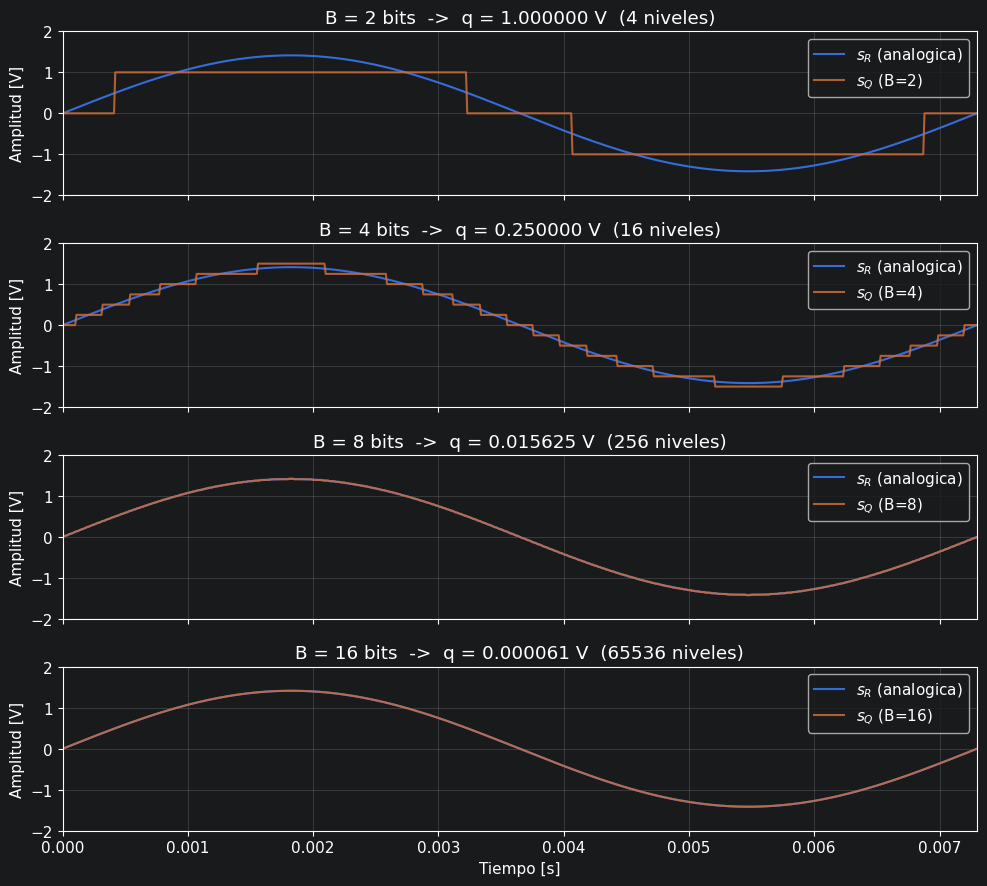

In [44]:
Vf = 2.0
Bs = [2, 4, 8, 16]

fig, axes = plt.subplots(len(Bs), 1, figsize=(10, 9), sharex=True)

for ax, B in zip(axes, Bs):
    sQ, q = cuantizar(sR, B, Vf)

    ax.plot(tt, sR, label="$s_R$ (analogica)", linewidth=1.5)
    ax.plot(tt, sQ, label=f"$s_Q$ (B={B})", linewidth=1.5, alpha=0.85)
    ax.set_ylim(-Vf, Vf)
    ax.set_ylabel("Amplitud [V]")
    ax.set_title(f"B = {B} bits  ->  q = {q:.6f} V  ({2**B} niveles)")
    ax.legend(loc="upper right")
    ax.set_xlim(tt[0], tt[0] + 1/f0)

axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

Como en 0 la pendiente del seno es maxima, el mayor error se producira en esa zona. Se hace un zoom para visualizar que en 16 bits es inperceptible

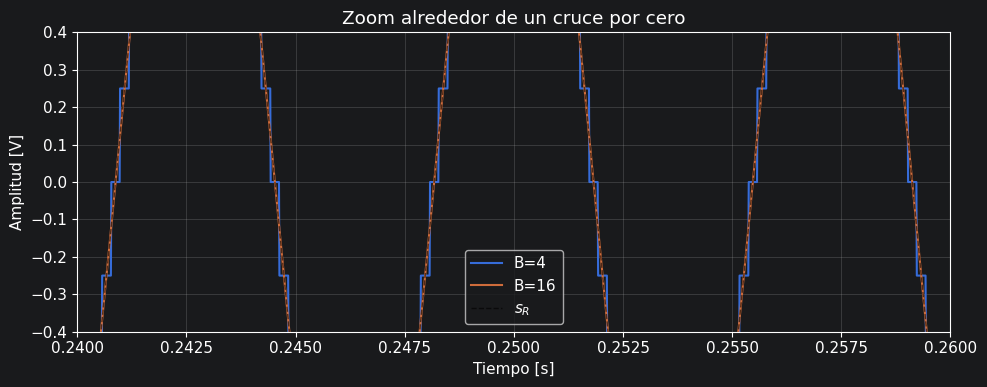

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))

for B in [4, 16]:
    sQ, q = cuantizar(sR, B, Vf)
    ax.plot(tt, sQ, label=f"B={B}", linewidth=1.5)

ax.plot(tt, sR, "k--", label="$s_R$", linewidth=1, alpha=0.6)
ax.set_xlim(0.24, 0.26)
ax.set_ylim(-0.4, 0.4)
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud [V]")
ax.set_title("Zoom alrededor de un cruce por cero")
ax.legend()
plt.tight_layout()
plt.show()

## BONUS: Analizar la señal de error verificando las descripciones estadísticas vistas en teoría (Distribución uniforme, media, varianza, incorrelación)

El error $e = s_Q - s_R$ se aproxima por una variable aleatoria:

- **uniforme** en $[-q/2,q/2]$,
- de **media** $\mu = 0$,
- de **varianza** $\sigma_e^2 = q^2/12$,


In [50]:
N = 100_000
fs = 100_000
f0 = 137.0
A = np.sqrt(2)
Vf = 2.0
B = 6

tt, sR = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
sQ, q = cuantizar(sR, B, Vf)
e = (sQ - sR).flatten()

print(f"B = {B} bits   q = {q:.6f} V")
print(f"Media muestral del error    : {np.mean(e):+.3e}   (esperada: 0)")
print(f"Varianza muestral del error : {np.var(e):.6e}")
print(f"q^2 / 12                    : {q**2/12:.6e}")

B = 6 bits   q = 0.062500 V
Media muestral del error    : -2.609e-18   (esperada: 0)
Varianza muestral del error : 3.540674e-04
q^2 / 12                    : 3.255208e-04


### Histograma del error:

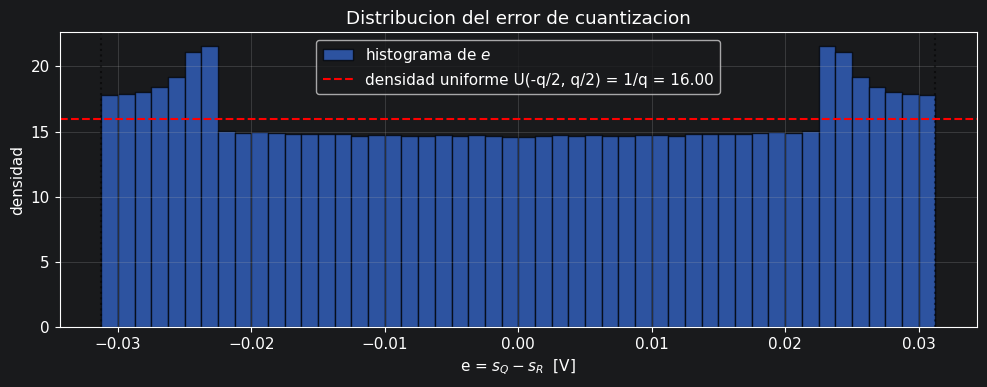

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(e, bins=50, density=True, alpha=0.7, edgecolor="k",
        label="histograma de $e$")

ax.axhline(1/q, color="red", linestyle="--",
           label=f"densidad uniforme U(-q/2, q/2) = 1/q = {1/q:.2f}")
ax.axvline(-q/2, color="k", linestyle=":", alpha=0.5)
ax.axvline( q/2, color="k", linestyle=":", alpha=0.5)

ax.set_xlabel("e = $s_Q - s_R$  [V]")
ax.set_ylabel("densidad")
ax.set_title("Distribucion del error de cuantizacion")
ax.legend()
plt.tight_layout()
plt.show()

### Incorrelación: autocorrelación de $e$ y correlación cruzada $e$–$s_R$

- Si $e$ es ruido blanco, su autocorrelación normalizada debería ser una delta en el origen.
- Si $e$ es independiente de $s_R$, la correlación cruzada debería estar cerca de cero para todos los retardos.

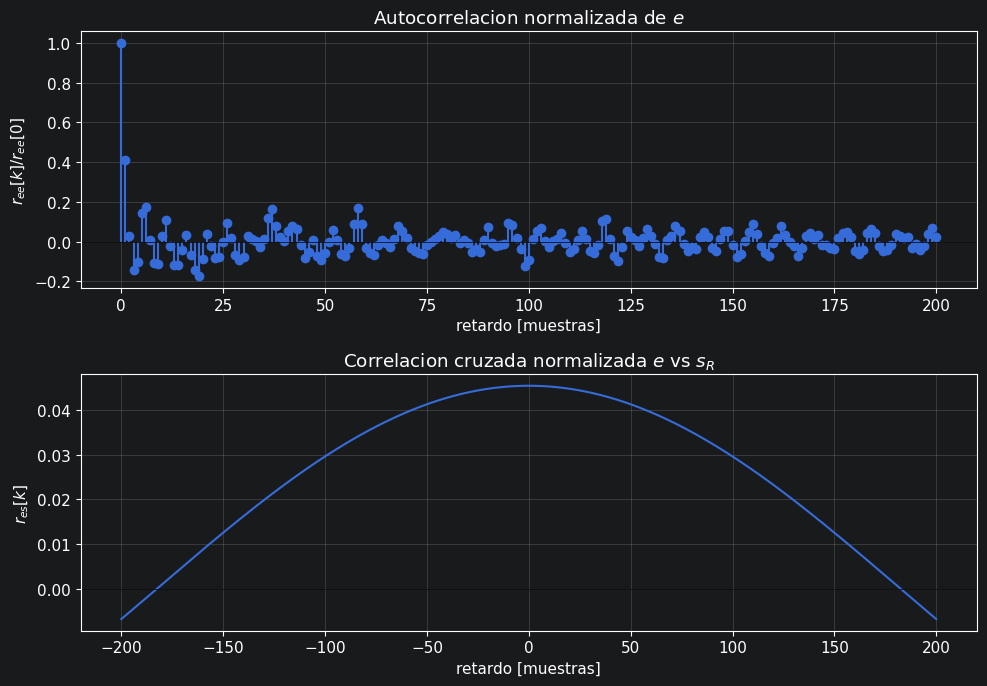

Maximo de |r_es| (k != 0): 4.5370e-02


In [40]:
def autocorr_norm(x, lags=200):
    x = x - np.mean(x)
    full = np.correlate(x, x, mode="full")
    mid = len(full) // 2
    r = full[mid : mid + lags + 1]
    return r / r[0]

def crosscorr_norm(x, y, lags=200):
    x = x - np.mean(x)
    y = y - np.mean(y)
    full = np.correlate(x, y, mode="full")
    mid = len(full) // 2
    r = full[mid - lags : mid + lags + 1]
    norm = np.sqrt(np.sum(x**2) * np.sum(y**2))
    return r / norm

lags = 200
r_ee = autocorr_norm(e, lags=lags)
r_es = crosscorr_norm(e, sR.flatten(), lags=lags)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].stem(np.arange(len(r_ee)), r_ee, basefmt=" ")
axes[0].set_title("Autocorrelacion normalizada de $e$")
axes[0].set_xlabel("retardo [muestras]")
axes[0].set_ylabel("$r_{ee}[k] / r_{ee}[0]$")
axes[0].axhline(0, color="k", linewidth=0.5)

axes[1].plot(np.arange(-lags, lags + 1), r_es)
axes[1].set_title("Correlacion cruzada normalizada $e$ vs $s_R$")
axes[1].set_xlabel("retardo [muestras]")
axes[1].set_ylabel("$r_{es}[k]$")
axes[1].axhline(0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Maximo de |r_es| (k != 0): {np.max(np.abs(r_es)):.4e}")

### Conclusiones

- El histograma del error se ajusta bien a la densidad uniforme $1/q$ entre $\pm q/2$.
- La media empírica es despreciable y la varianza coincide con $q^2/12$ (cociente $\approx 1$).
- La autocorrelación se concentra en el origen y la correlación cruzada con $s_R$ queda en niveles muy bajos: el error es aproximadamente blanco e incorrelacionado con la señal.

Estas son las hipótesis estándar del **modelo de ruido aditivo de cuantización**, que permiten tratar al error como ruido blanco y derivar la conocida relación SNR$_q \approx 6{,}02\,B + 1{,}76$ dB para entradas senoidales que ocupan todo el rango.